## Joins and merges

In [9]:
import pandas as pd
import numpy as np

data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve", "Alice"],
    "Age": [25, 30, 35, np.nan, 29, 25],
    "Dept": ["HR", "IT", "Finance", "IT", "HR", "HR"],
    "Salary": [50000, 60000, 70000, 62000, np.nan, 50000]
}

In [10]:
department_info = {
    "Dept": ["HR", "IT", "Finance"],
    "Location": ["New York", "San Francisco", "Chicago"],
    "Manager": ["Laura", "Steve", "Nina"]
}

df = pd.DataFrame(data);
df2 = pd.DataFrame(department_info);

In [11]:
#Concat

pd.concat([df , df2])

,Name,Age,Dept,Salary,Location,Manager
0,Alice,25.0,HR,50000.0,NaN,NaN
1,Bob,30.0,IT,60000.0,NaN,NaN
2,Charlie,35.0,Finance,70000.0,NaN,NaN
3,David,NaN,IT,62000.0,NaN,NaN
4,Eve,29.0,HR,NaN,NaN,NaN
5,Alice,25.0,HR,50000.0,NaN,NaN
0,NaN,NaN,HR,NaN,New York,Laura
1,NaN,NaN,IT,NaN,San Francisco,Steve
2,NaN,NaN,Finance,NaN,Chicago,Nina


In [12]:
pd.concat([df , df2] , axis=1)

,Name,Age,Dept,Salary,Dept,Location,Manager
0,Alice,25.0,HR,50000.0,HR,New York,Laura
1,Bob,30.0,IT,60000.0,IT,San Francisco,Steve
2,Charlie,35.0,Finance,70000.0,Finance,Chicago,Nina
3,David,NaN,IT,62000.0,NaN,NaN,NaN
4,Eve,29.0,HR,NaN,NaN,NaN,NaN
5,Alice,25.0,HR,50000.0,NaN,NaN,NaN


In [26]:
df = df.drop_duplicates()
print(df)
df3 = pd.merge(df , df2 , on ="Dept")
df3


      Name   Age     Dept   Salary
0    Alice  25.0       HR  50000.0
1      Bob  30.0       IT  60000.0
2  Charlie  35.0  Finance  70000.0
3    David   NaN       IT  62000.0
4      Eve  29.0       HR      NaN


,Name,Age,Dept,Salary,Location,Manager
0,Alice,25.0,HR,50000.0,New York,Laura
1,Bob,30.0,IT,60000.0,San Francisco,Steve
2,Charlie,35.0,Finance,70000.0,Chicago,Nina
3,David,NaN,IT,62000.0,San Francisco,Steve
4,Eve,29.0,HR,NaN,New York,Laura


### Group by

In [27]:
g = df3.groupby('Dept')
g

In [28]:
for dept , dept_df in g:
    print(dept)
    print(dept_df)

Finance
      Name   Age     Dept   Salary Location Manager
2  Charlie  35.0  Finance  70000.0  Chicago    Nina
HR
    Name   Age Dept   Salary  Location Manager
0  Alice  25.0   HR  50000.0  New York   Laura
4    Eve  29.0   HR      NaN  New York   Laura
IT
    Name   Age Dept   Salary       Location Manager
1    Bob  30.0   IT  60000.0  San Francisco   Steve
3  David   NaN   IT  62000.0  San Francisco   Steve


In [29]:
g.get_group('HR')

,Name,Age,Dept,Salary,Location,Manager
0,Alice,25.0,HR,50000.0,New York,Laura
4,Eve,29.0,HR,NaN,New York,Laura


In [ ]:
g.max() 
# split - apply - combine

,Name,Age,Salary,Location,Manager
Dept,,,,,
Finance,Charlie,35.0,70000.0,Chicago,Nina
HR,Eve,29.0,50000.0,New York,Laura
IT,David,30.0,62000.0,San Francisco,Steve


In [34]:
g.describe()

Age                                               Salary           \
        count  mean       std   min   25%   50%   75%   max  count     mean   
Dept                                                                          
Finance   1.0  35.0       NaN  35.0  35.0  35.0  35.0  35.0    1.0  70000.0   
HR        2.0  27.0  2.828427  25.0  26.0  27.0  28.0  29.0    1.0  50000.0   
IT        1.0  30.0       NaN  30.0  30.0  30.0  30.0  30.0    2.0  61000.0   

                                                                   
                 std      min      25%      50%      75%      max  
Dept                                                               
Finance          NaN  70000.0  70000.0  70000.0  70000.0  70000.0  
HR               NaN  50000.0  50000.0  50000.0  50000.0  50000.0  
IT       1414.213562  60000.0  60500.0  61000.0  61500.0  62000.0

<Axes: xlabel='Dept'>

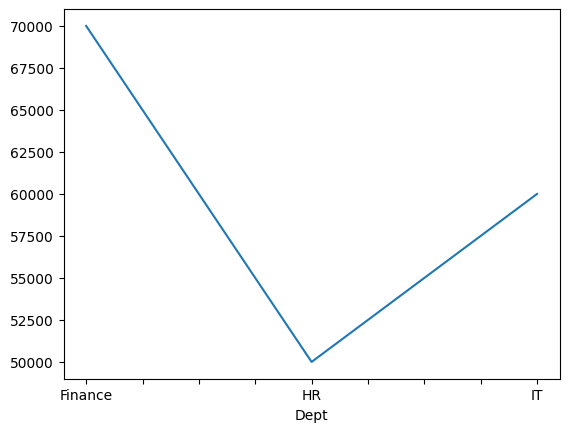

In [37]:
%matplotlib inline
g['Salary'].min().plot()

In [17]:
data = pd.read_csv("data.csv")
data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [ ]:
data.head() #first 5 rows

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [19]:
data.shape

(4600, 18)

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [24]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[us]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4600 non-null   str           
 15  city           4600 non-null   s